## Notebook 15 – Mini Assessment

### Installing the Libraries
I am installing numpy, pandas, scipy, matplotlib and seaborn because the coding exercises below need them for calculations, statistical tests and charts.

In [1]:
!pip install numpy pandas scipy matplotlib seaborn

### Importing the Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### Sample Data

In [3]:
np.random.seed(42)

marks = [45, 52, 58, 60, 62, 65, 68, 70, 72, 75, 78, 95]
salaries = [30, 32, 35, 36, 38, 40, 42, 45, 48, 150]      # in thousands

hours = [1, 2, 3, 4, 5, 6, 7, 8]
scores = [35, 42, 50, 55, 62, 70, 74, 85]
attendance = [60, 65, 70, 72, 78, 82, 88, 95]

# Part A – Theory Questions

### Descriptive Statistics
Explain the difference between Mean and Median.</br>

Answer: Mean is the average of all values, while Median is the middle value when the data is arranged in order.

When would you prefer Median over Mean?</br>

Answer: When the dataset contains outliers or extreme values.

What is Variance?</br>

Answer: Variance measures how much the data values differ from the mean.

What is Standard Deviation?</br>

Answer: Standard Deviation measures the spread of data around the mean.

Explain the difference between Population and Sample.</br>

Answer: Population is the complete group being studied, while Sample is a smaller subset selected from the population.

Explain the difference between Descriptive and Inferential Statistics.</br>

Answer: Descriptive Statistics summarizes the given data, while Inferential Statistics uses sample data to make conclusions about a population.

What is Skewness?</br>

Answer: Skewness measures the asymmetry of a data distribution.

Explain IQR.</br>

Answer: IQR (Interquartile Range) represents the middle 50% of the data.
IQR = Q3 − Q1

What is Kurtosis?</br>

Answer: Kurtosis measures the heaviness of the tails and the peakedness of a distribution.

State the Empirical Rule (68–95–99.7).</br>

Answer:

68% of data lies within 1 standard deviation.
95% of data lies within 2 standard deviations.
99.7% of data lies within 3 standard deviations.

### Probability
Explain Bayes' Theorem with an example.</br>

Answer: Bayes' Theorem calculates the probability of an event based on prior knowledge and new evidence.

Example: If a medical test is positive, Bayes' Theorem can be used to calculate the probability that the person actually has the disease.

What is Conditional Probability?</br>

Answer: Conditional Probability is the probability of an event occurring given that another event has already occurred.

What is the difference between Independent and Dependent Events?</br>

Answer:

Independent Events: The occurrence of one event does not affect the probability of another event.
Dependent Events: The occurrence of one event affects the probability of another event.

What is Expected Value?</br>

Answer: Expected Value is the weighted average of all possible outcomes based on their probabilities.

What is the difference between Binomial and Poisson Distribution?</br>

Answer:

Binomial Distribution: Used for a fixed number of independent trials with two possible outcomes.
Poisson Distribution: Used to model the number of events occurring within a fixed interval of time or space.

# Part B – Coding Exercises

**Exercise 1.** Calculate the Mean, Median and Mode of the `marks` list.

In [4]:
from collections import Counter

mean_value = sum(marks) / len(marks)

sorted_marks = sorted(marks)
n = len(sorted_marks)
median_value = sorted_marks[n // 2] if n % 2 == 1 else (sorted_marks[n // 2 - 1] + sorted_marks[n // 2]) / 2

mode_value = Counter(marks).most_common(1)[0][0]

print("Mean:", round(mean_value, 2))
print("Median:", median_value)
print("Mode:", mode_value)

Mean: 66.67
Median: 66.5
Mode: 45


**Exercise 2.** Write Python code to calculate the Variance of the `marks` list (population and sample) and verify it with NumPy.

In [5]:
mean_value = sum(marks) / len(marks)
squared_diffs = [(x - mean_value) ** 2 for x in marks]

population_variance = sum(squared_diffs) / len(marks)
sample_variance = sum(squared_diffs) / (len(marks) - 1)

print("Population Variance:", round(population_variance, 2))
print("Sample Variance:", round(sample_variance, 2))
print("NumPy check:", round(np.var(marks), 2), round(np.var(marks, ddof=1), 2))

Population Variance: 155.89
Sample Variance: 170.06
NumPy check: 155.89 170.06


**Exercise 3.** Calculate the Standard Deviation of the `marks` list.

In [6]:
population_std = np.sqrt(np.var(marks))
sample_std = np.sqrt(np.var(marks, ddof=1))

print("Population Standard Deviation:", round(population_std, 2))
print("Sample Standard Deviation:", round(sample_std, 2))

Population Standard Deviation: 12.49
Sample Standard Deviation: 13.04


**Exercise 4.** Calculate the Range, Q1, Q3 and IQR of the `marks` list.

In [7]:
range_value = max(marks) - min(marks)
q1 = np.percentile(marks, 25)
q3 = np.percentile(marks, 75)
iqr = q3 - q1

print("Range:", range_value)
print("Q1:", q1, " Q3:", q3)
print("IQR:", iqr)

Range: 50
Q1: 59.5  Q3: 72.75
IQR: 13.25


**Exercise 5.** Detect Outliers in the `salaries` list using the IQR Method.

In [8]:
q1 = np.percentile(salaries, 25)
q3 = np.percentile(salaries, 75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = [x for x in salaries if x < lower_bound or x > upper_bound]
print("Lower bound:", lower_bound, " Upper bound:", upper_bound)
print("Outliers:", outliers)

Lower bound: 21.75  Upper bound: 57.75
Outliers: [150]


**Exercise 6.** Detect Outliers in the `salaries` list using the Z-Score Method (use |z| > 2 as the cutoff).

In [9]:
mean_value = np.mean(salaries)
std_value = np.std(salaries)

z_scores = [(x - mean_value) / std_value for x in salaries]
outliers = [salaries[i] for i in range(len(salaries)) if abs(z_scores[i]) > 2]

print("Z-scores:", [round(z, 2) for z in z_scores])
print("Outliers:", outliers)

Z-scores: [np.float64(-0.58), np.float64(-0.52), np.float64(-0.43), np.float64(-0.4), np.float64(-0.34), np.float64(-0.28), np.float64(-0.22), np.float64(-0.14), np.float64(-0.05), np.float64(2.96)]
Outliers: [150]


**Exercise 7.** Calculate the Pearson Correlation between `hours` and `scores`.

In [10]:
mean_h, mean_s = np.mean(hours), np.mean(scores)

numerator = sum((h - mean_h) * (s - mean_s) for h, s in zip(hours, scores))
denominator = np.sqrt(sum((h - mean_h) ** 2 for h in hours) * sum((s - mean_s) ** 2 for s in scores))

correlation = numerator / denominator
print("Correlation (manual):", round(correlation, 4))
print("Correlation (NumPy):", round(np.corrcoef(hours, scores)[0][1], 4))

Correlation (manual): 0.9972
Correlation (NumPy): 0.9972


**Exercise 8.** Calculate the Covariance between `hours` and `scores`.

In [11]:
mean_h, mean_s = np.mean(hours), np.mean(scores)

covariance = sum((h - mean_h) * (s - mean_s) for h, s in zip(hours, scores)) / len(hours)
print("Covariance (manual):", round(covariance, 2))
print("Covariance (NumPy):", round(np.cov(hours, scores, bias=True)[0][1], 2))

Covariance (manual): 36.06
Covariance (NumPy): 36.06


**Exercise 9.** Calculate the Skewness of the `marks` list and print whether it is right skewed, left skewed or symmetric.

In [12]:
skewness = stats.skew(marks)
print("Skewness:", round(skewness, 3))

if skewness > 0.5:
    print("Right skewed")
elif skewness < -0.5:
    print("Left skewed")
else:
    print("Approximately symmetric")

Skewness: 0.453
Approximately symmetric


**Exercise 10.** Use Bayes' Theorem to find the probability that a person has a disease given a positive test. 1% of people have the disease, the test is positive for 95% of people who have it, and it is positive for 5% of people who do not.

In [13]:
p_disease = 0.01
p_positive_given_disease = 0.95
p_positive_given_healthy = 0.05

p_positive = p_positive_given_disease * p_disease + p_positive_given_healthy * (1 - p_disease)
p_disease_given_positive = (p_positive_given_disease * p_disease) / p_positive

print("P(Disease | Positive):", round(p_disease_given_positive, 4))

P(Disease | Positive): 0.161


**Exercise 11.** A game costs 10 to play. You win 100 with probability 0.05, win 20 with probability 0.10, and win nothing otherwise. Calculate the Expected Value of the winnings and of the net profit.

In [14]:
outcomes = [100, 20, 0]
probabilities = [0.05, 0.10, 0.85]

expected_winnings = sum(x * p for x, p in zip(outcomes, probabilities))
expected_profit = expected_winnings - 10

print("Expected winnings:", expected_winnings)
print("Expected net profit:", expected_profit)

Expected winnings: 7.0
Expected net profit: -3.0


**Exercise 12.** Generate 10,000 normally distributed values (mean 50, standard deviation 10) and check the Empirical Rule.

In [15]:
data = np.random.normal(50, 10, 10000)
mean_value, std_value = np.mean(data), np.std(data)

for k in [1, 2, 3]:
    share = np.mean((data > mean_value - k * std_value) & (data < mean_value + k * std_value)) * 100
    print(f"Within {k} standard deviation(s): {share:.1f}%")

Within 1 standard deviation(s): 68.4%
Within 2 standard deviation(s): 95.4%
Within 3 standard deviation(s): 99.7%


**Exercise 13.** Draw a random sample of 30 values from a population of 10,000 and compare the sample mean with the population mean.

In [16]:
population = np.random.normal(170, 10, 10000)
sample = np.random.choice(population, size=30, replace=False)

print("Population mean:", round(population.mean(), 2))
print("Sample mean:", round(sample.mean(), 2))
print("Sampling error:", round(sample.mean() - population.mean(), 2))

Population mean: 170.14
Sample mean: 169.13
Sampling error: -1.01


**Exercise 14.** Perform a two-sample T-Test on the two groups below and print the decision at the 0.05 significance level.

In [17]:
group_a = [72, 75, 78, 80, 74, 77, 79]
group_b = [65, 68, 70, 66, 69, 64, 67]

t_stat, p_value = stats.ttest_ind(group_a, group_b)
print("T-statistic:", round(t_stat, 3))
print("p-value:", round(p_value, 5))

if p_value < 0.05:
    print("Reject the Null Hypothesis")
else:
    print("Fail to reject the Null Hypothesis")

T-statistic: 6.931
p-value: 2e-05
Reject the Null Hypothesis


**Exercise 15.** Calculate the probability of getting exactly 3 successes in 10 trials when the probability of success is 0.4 (Binomial Distribution).

In [18]:
probability = stats.binom.pmf(3, 10, 0.4)
print("P(X = 3):", round(probability, 4))

P(X = 3): 0.215


**Exercise 16.** Create a DataFrame from `hours`, `scores` and `attendance`, then draw its correlation matrix as a heatmap.

            hours  scores  attendance
hours        1.00     1.0        0.99
scores       1.00     1.0        1.00
attendance   0.99     1.0        1.00


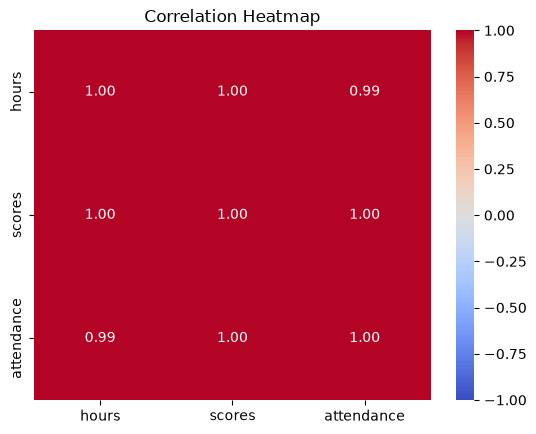

In [19]:
df = pd.DataFrame({"hours": hours, "scores": scores, "attendance": attendance})
print(df.corr().round(2))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**Exercise 17.** Standardize (z-score) and Normalize (min-max) the `marks` list without using scikit-learn.

In [22]:
mean_value, std_value = np.mean(marks), np.std(marks)
min_value, max_value = min(marks), max(marks)

standardized = [round((x - mean_value) / std_value, 2) for x in marks]
normalized = [round((x - min_value) / (max_value - min_value), 2) for x in marks]

print("Standardized:", standardized)
print("Normalized:  ", normalized)

Standardized: [np.float64(-1.74), np.float64(-1.17), np.float64(-0.69), np.float64(-0.53), np.float64(-0.37), np.float64(-0.13), np.float64(0.11), np.float64(0.27), np.float64(0.43), np.float64(0.67), np.float64(0.91), np.float64(2.27)]
Normalized:   [0.0, 0.14, 0.26, 0.3, 0.34, 0.4, 0.46, 0.5, 0.54, 0.6, 0.66, 1.0]
